# Scaffold Overlap and Nearest-Neighbour Similarity Analysis

This notebook performs chemical diversity and overlap analysis between the training set (`HDAC8_train.sdf`) and test set (`HDAC8_test.sdf`):
1. **Bemis–Murcko Scaffold Analysis**: Extraction of unique scaffolds for each dataset and evaluation of their overlap.
2. **Nearest-Neighbour Similarity Assessment**: Calculation of ECFP4 fingerprints (`MorganGenerator`, radius=2, fpSize=1024) for all molecules, identification of the maximum Tanimoto similarity ($T_c$) for each test compound against the training set, computation of mean ± SD $T_c$, and determination of the proportion of test compounds with $T_c \ge 0.85$ (close analogues).
3. **Visualization**: Histogram/KDE of $T_c$ distribution and Empirical Cumulative Distribution Function (ECDF) plot.
4. **Export**: Per-compound results, summary statistics, and a manuscript-ready text paragraph.


Loaded molecules from HDAC8_train.sdf: 2092
Loaded molecules from HDAC8_test.sdf: 524
BEMIS-MURCKO SCAFFOLD OVERLAP RESULTS:
Unique scaffolds in training set: 1131
Unique scaffolds in test set: 386
Shared scaffolds (overlap count): 192
Scaffold overlap percentage (relative to test set): 49.74%

NEAREST-NEIGHBOUR SIMILARITY RESULTS (ECFP4 / TANIMOTO):
Mean max Tc: 0.7501 ± 0.1549
Median max Tc: 0.7674
Compounds with Tc >= 0.85 (close analogues): 108 / 524 (20.61%)

MANUSCRIPT-READY TEXT:
Nearest-Neighbour Similarity and Scaffold Overlap Analysis:

Nearest-Neighbour Similarity: For each compound in the test set, the maximum Tanimoto similarity ($T_c$) to any compound in the training set was calculated using ECFP4 fingerprints. The mean nearest-neighbour Tanimoto similarity was 0.75 ± 0.15. Only 20.6% of the test set compounds exhibited high structural similarity ($T_c \ge 0.85$) to training set molecules.

Scaffold Overlap: Bemis–Murcko structural scaffolds were generated for all molecul

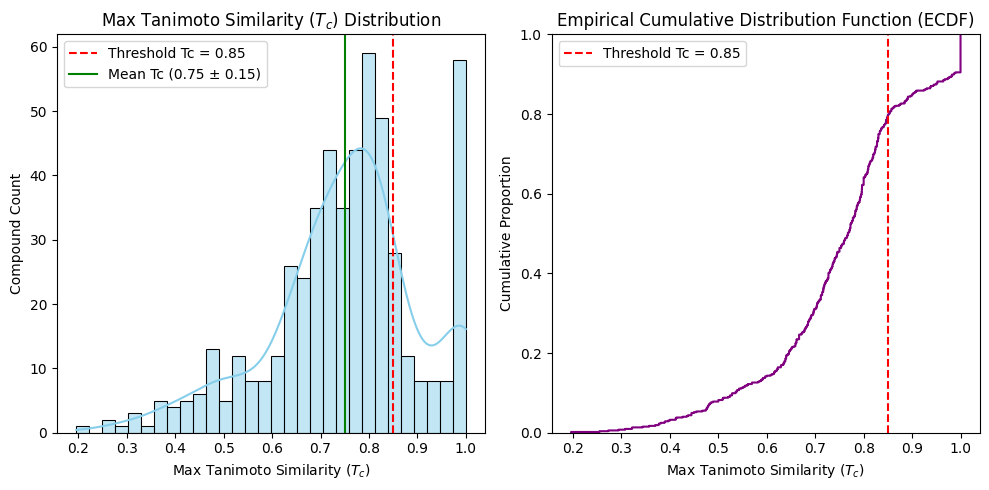


Results successfully saved to:
  - test_similarity_analysis_results.csv
  - similarity_analysis_summary.csv
  - similarity_analysis_manuscript_text.txt


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from rdkit import Chem
from rdkit.Chem import DataStructs
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator

# 1. Load Datasets
def load_sdf(filepath):
    suppl = Chem.SDMolSupplier(filepath)
    mols = [mol for mol in suppl if mol is not None]
    print(f"Loaded molecules from {filepath}: {len(mols)}")
    return mols

train_mols = load_sdf("HDAC8_train.sdf")
test_mols = load_sdf("HDAC8_test.sdf")

# 2. Bemis–Murcko Scaffold Analysis
def get_bemis_murcko_scaffolds(mols):
    scaffolds = set()
    scaffold_list = []
    for mol in mols:
        try:
            scaffold = MurckoScaffold.GetScaffoldForMol(mol)
            smiles = Chem.MolToSmiles(scaffold)
            scaffolds.add(smiles)
            scaffold_list.append(smiles)
        except Exception as e:
            scaffold_list.append(None)
    return scaffolds, scaffold_list

train_scaffolds, train_scaff_list = get_bemis_murcko_scaffolds(train_mols)
test_scaffolds, test_scaff_list = get_bemis_murcko_scaffolds(test_mols)

overlap_scaffolds = train_scaffolds.intersection(test_scaffolds)
overlap_percentage = (len(overlap_scaffolds) / len(test_scaffolds) * 100) if test_scaffolds else 0

print("=" * 55)
print("BEMIS-MURCKO SCAFFOLD OVERLAP RESULTS:")
print(f"Unique scaffolds in training set: {len(train_scaffolds)}")
print(f"Unique scaffolds in test set: {len(test_scaffolds)}")
print(f"Shared scaffolds (overlap count): {len(overlap_scaffolds)}")
print(f"Scaffold overlap percentage (relative to test set): {overlap_percentage:.2f}%")
print("=" * 55)

# 3. ECFP4 Calculation (Morgan Generator, radius=2, fpSize=1024)
morgan_gen = GetMorganGenerator(radius=2, fpSize=1024)

def get_fps(mols):
    return [morgan_gen.GetFingerprint(mol) for mol in mols]

train_fps = get_fps(train_mols)
test_fps = get_fps(test_mols)

# 4. Nearest-Neighbour Similarity Calculation (Max Tanimoto Similarity)
max_tc_list = []
for test_fp in test_fps:
    sims = DataStructs.BulkTanimotoSimilarity(test_fp, train_fps)
    max_tc = max(sims)
    max_tc_list.append(max_tc)

max_tc_arr = np.array(max_tc_list)
mean_tc = np.mean(max_tc_arr)
std_tc = np.std(max_tc_arr, ddof=1)
median_tc = np.median(max_tc_arr)
high_sim_count = np.sum(max_tc_arr >= 0.85)
high_sim_ratio = (high_sim_count / len(test_mols)) * 100

print("\n" + "=" * 55)
print("NEAREST-NEIGHBOUR SIMILARITY RESULTS (ECFP4 / TANIMOTO):")
print(f"Mean max Tc: {mean_tc:.4f} ± {std_tc:.4f}")
print(f"Median max Tc: {median_tc:.4f}")
print(f"Compounds with Tc >= 0.85 (close analogues): {high_sim_count} / {len(test_mols)} ({high_sim_ratio:.2f}%)")
print("=" * 55)

# Manuscript-ready summary paragraph
manuscript_text = f"""Nearest-Neighbour Similarity and Scaffold Overlap Analysis:

Nearest-Neighbour Similarity: For each compound in the test set, the maximum Tanimoto similarity ($T_c$) to any compound in the training set was calculated using ECFP4 fingerprints. The mean nearest-neighbour Tanimoto similarity was {mean_tc:.2f} ± {std_tc:.2f}. Only {high_sim_ratio:.1f}% of the test set compounds exhibited high structural similarity ($T_c \\ge 0.85$) to training set molecules.

Scaffold Overlap: Bemis–Murcko structural scaffolds were generated for all molecules using RDKit. The training set contained {len(train_scaffolds)} unique scaffolds, while the test set contained {len(test_scaffolds)} unique scaffolds. The scaffold overlap between the training and test sets was {overlap_percentage:.1f}%, indicating that while some shared scaffold cores exist, a substantial fraction of the test set consists of distinct structural topologies."""

print("\n" + "=" * 55)
print("MANUSCRIPT-READY TEXT:")
print("=" * 55)
print(manuscript_text)
print("=" * 55)

# 5. Visualizing Similarity Distribution
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
sns.histplot(max_tc_arr, bins=30, kde=True, color='skyblue', edgecolor='black')
plt.axvline(0.85, color='red', linestyle='--', label='Threshold Tc = 0.85')
plt.axvline(mean_tc, color='green', linestyle='-', label=f'Mean Tc ({mean_tc:.2f} ± {std_tc:.2f})')
plt.title('Max Tanimoto Similarity ($T_c$) Distribution')
plt.xlabel('Max Tanimoto Similarity ($T_c$)')
plt.ylabel('Compound Count')
plt.legend()

plt.subplot(1, 2, 2)
sns.ecdfplot(max_tc_arr, color='purple')
plt.axvline(0.85, color='red', linestyle='--', label='Threshold Tc = 0.85')
plt.title('Empirical Cumulative Distribution Function (ECDF)')
plt.xlabel('Max Tanimoto Similarity ($T_c$)')
plt.ylabel('Cumulative Proportion')
plt.legend()

plt.tight_layout()
plt.savefig("scaffold_and_similarity_analysis.png", dpi=300)
plt.show()

# 6. Export Results to CSV
df_res = pd.DataFrame({
    'Test_Mol_Index': list(range(1, len(test_mols) + 1)),
    'Max_Tanimoto_Similarity': max_tc_list,
    'Scaffold_SMILES': test_scaff_list,
    'Is_Scaffold_In_Train': [s in train_scaffolds for s in test_scaff_list]
})
df_res.to_csv("test_similarity_analysis_results.csv", index=False)

summary_stats = pd.DataFrame([{
    'Mean_Max_Tc': mean_tc,
    'Std_Max_Tc': std_tc,
    'Median_Max_Tc': median_tc,
    'High_Sim_Count_Tc_ge_0.85': high_sim_count,
    'High_Sim_Percentage': high_sim_ratio,
    'Train_Unique_Scaffolds': len(train_scaffolds),
    'Test_Unique_Scaffolds': len(test_scaffolds),
    'Shared_Scaffolds': len(overlap_scaffolds),
    'Scaffold_Overlap_Percentage': overlap_percentage,
}])
summary_stats.to_csv("similarity_analysis_summary.csv", index=False)

with open("similarity_analysis_manuscript_text.txt", "w", encoding="utf-8") as f:
    f.write(manuscript_text)

print("\nResults successfully saved to:")
print("  - test_similarity_analysis_results.csv")
print("  - similarity_analysis_summary.csv")
print("  - similarity_analysis_manuscript_text.txt")
